<a href="https://colab.research.google.com/github/barta102-bot/NLP-Logical-Fallacy-Detection/blob/main/FallacyDetection_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Fallacy Detection in Political Debates
**Based on:** [Goffredo et al., EMNLP 2023](https://aclanthology.org/2023.emnlp-main.684/)  
**Repo:** [pierpaologoffredo/FallacyDetection](https://github.com/pierpaologoffredo/FallacyDetection)

---

### 📋 Table of Contents
1. [Environment Setup](#setup)
2. [Data Exploration](#exploration)
3. [Preprocessing & Data Pipeline](#preprocessing)
4. [Model Definition](#model)
5. [Training](#training)
6. [Evaluation](#evaluation)

---
> ⚠️ **Before running:** Go to `Runtime > Change runtime type > GPU (T4)`

<a name="setup"></a>
## 1. Environment Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install dependencies
!pip install transformers==4.28.0 seqeval spacy scikit-learn -q
!python -m spacy download en_core_web_sm -q
print('✅ Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 26.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
     ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Create project folder structure on Drive
import os

PROJECT_ROOT = '/content/drive/MyDrive/FallacyDetection'
REPO_DIR     = f'{PROJECT_ROOT}/repo'
DATA_DIR     = f'{PROJECT_ROOT}/data'
CKPT_DIR     = f'{PROJECT_ROOT}/checkpoints'
LOG_DIR      = f'{PROJECT_ROOT}/logs'

for d in [REPO_DIR, DATA_DIR, CKPT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f'  ✅ {d}')

  ✅ /content/drive/MyDrive/FallacyDetection/repo
  ✅ /content/drive/MyDrive/FallacyDetection/data
  ✅ /content/drive/MyDrive/FallacyDetection/checkpoints
  ✅ /content/drive/MyDrive/FallacyDetection/logs


In [ ]:
# Clone the repo
if not os.path.exists(f'{REPO_DIR}/.git'):
    !git clone https://github.com/pierpaologoffredo/FallacyDetection {REPO_DIR}
    print('✅ Repo cloned.')
else:
    !cd {REPO_DIR} && git pull
    print('✅ Repo up to date.')

Cloning into '/content/drive/MyDrive/FallacyDetection/repo'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 108 (delta 49), reused 85 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 2.06 MiB | 7.66 MiB/s, done.
Resolving deltas: 100% (49/49), done.
✅ Repo cloned.


In [ ]:
# Verify GPU
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — go to Runtime > Change runtime type > GPU')

torch.manual_seed(42)
import numpy as np
np.random.seed(42)

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


<a name="exploration"></a>
## 2. Data Exploration

In [ ]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

# Load the raw CSVs from the repo
train_raw = pd.read_csv(f'{REPO_DIR}/data/pos_train_set.csv')
test_raw  = pd.read_csv(f'{REPO_DIR}/data/pos_test_set.csv')

print(f'Train shape : {train_raw.shape}')
print(f'Test shape  : {test_raw.shape}')
print(f'Columns     : {list(train_raw.columns)}')

Train shape : (1790, 9)
Test shape  : (199, 9)
Columns     : ['Date', 'Fallacy', 'Label', 'Subcategory', 'arg_comp', 'arg_rel', 'Context', 'bio_tags', 'pos_tags']


In [ ]:
# Preview
train_raw.head(3)

,Date,Fallacy,Label,Subcategory,arg_comp,arg_rel,Context,bio_tags,pos_tags
0,2004,"In fact, it's starting to fall apart not becau...",FalseCause,False cause,Premise,Attack,"And there is no system. In fact, it's starting...","['O', 'O', 'O', 'O', 'O', 'B-FalseCause', 'I-F...","CCONJ,PRON,VERB,DET,NOUN,PUNCT,ADP,NOUN,PUNCT,..."
1,1976,We've got an extraordinarily high unemployment...,AppealtoEmotion,Appeal to pity,Premise,Support,The last point is that the major - uh thrust h...,"['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","DET,ADJ,NOUN,AUX,SCONJ,DET,ADJ,PUNCT,INTJ,NOUN..."
2,2008,Admiral Mullen suggests that Senator Obama's p...,AppealtoAuthority,Without Evidence,Claim,NaN,"And right now, the commanders in Afghanistan, ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...","CCONJ,ADV,ADV,PUNCT,DET,NOUN,ADP,PROPN,PUNCT,A..."


In [ ]:
# Null check
print('=== Nulls (train) ==='); print(train_raw.isnull().sum())
print('\n=== Nulls (test) ===');  print(test_raw.isnull().sum())

=== Nulls (train) ===
Date             0
Fallacy          0
Label            0
Subcategory    218
arg_comp       112
arg_rel        564
Context          0
bio_tags         0
pos_tags         0
dtype: int64

=== Nulls (test) ===
Date            0
Fallacy         0
Label           0
Subcategory    24
arg_comp       15
arg_rel        68
Context         0
bio_tags        0
pos_tags        0
dtype: int64


In [ ]:
# Token-level BIO label distribution
LABELS = [
    'B-AdHominem','I-AdHominem',
    'B-AppealtoAuthority','I-AppealtoAuthority',
    'B-AppealtoEmotion','I-AppealtoEmotion',
    'B-FalseCause','I-FalseCause',
    'B-Slipperyslope','I-Slipperyslope',
    'B-Slogans','I-Slogans',
    'O'
]

def count_labels(df):
    c = Counter()
    for s in df['bio_tags']:
        c.update(ast.literal_eval(s))
    return c

train_counts = count_labels(train_raw)
test_counts  = count_labels(test_raw)

print(f'{"Label":<30} {"Train":>8} {"Test":>8}')
print('-' * 50)
for lbl in LABELS:
    print(f'{lbl:<30} {train_counts.get(lbl,0):>8} {test_counts.get(lbl,0):>8}')

Label                             Train     Test
--------------------------------------------------
B-AdHominem                         243       27
I-AdHominem                        4855      712
B-AppealtoAuthority                 272       30
I-AppealtoAuthority                8707     1019
B-AppealtoEmotion                  1073      120
I-AppealtoEmotion                 17408     2104
B-FalseCause                         84        9
I-FalseCause                       3076      312
B-Slipperyslope                      71        8
I-Slipperyslope                    2487      324
B-Slogans                            47        5
I-Slogans                           254       44
O                                 74493     7914


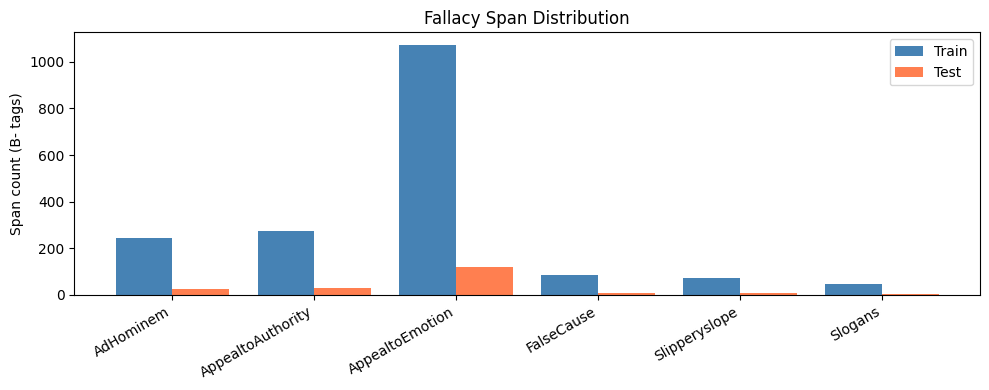

In [ ]:
# Class distribution plot (B- tags = span starts)
b_labels    = [l for l in LABELS if l.startswith('B-')]
clean_names = [l.replace('B-','') for l in b_labels]
x = range(len(b_labels))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i-0.2 for i in x], [train_counts.get(l,0) for l in b_labels], 0.4, label='Train', color='steelblue')
ax.bar([i+0.2 for i in x], [test_counts.get(l,0)  for l in b_labels], 0.4, label='Test',  color='coral')
ax.set_xticks(list(x)); ax.set_xticklabels(clean_names, rotation=30, ha='right')
ax.set_ylabel('Span count (B- tags)'); ax.set_title('Fallacy Span Distribution')
ax.legend(); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/class_distribution.png', dpi=150); plt.show()

=== Sequence length stats (train) ===
count    1790.000000
mean       63.167598
std        29.885413
min         5.000000
25%        42.000000
50%        58.000000
75%        80.000000
max       215.000000
Name: Context, dtype: float64
Sequences > 256 tokens: 0


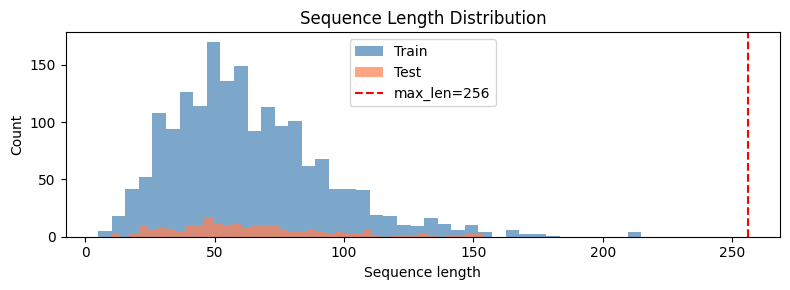

In [ ]:
# Sequence length analysis (BERT has a 512-token limit)
train_lens = train_raw['Context'].apply(lambda x: len(x.strip().split()))
test_lens  = test_raw['Context'].apply(lambda x: len(x.strip().split()))

print('=== Sequence length stats (train) ===')
print(train_lens.describe())
print(f'Sequences > 256 tokens: {(train_lens > 256).sum()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(train_lens, bins=40, color='steelblue', alpha=0.7, label='Train')
ax.hist(test_lens,  bins=40, color='coral',     alpha=0.7, label='Test')
ax.axvline(256, color='red', linestyle='--', label='max_len=256')
ax.set_xlabel('Sequence length'); ax.set_ylabel('Count')
ax.set_title('Sequence Length Distribution'); ax.legend()
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/sequence_lengths.png', dpi=150); plt.show()

In [ ]:
# Inspect a few annotated examples
for i, row in train_raw.head(3).iterrows():
    tokens = row['Context'].strip().split()
    tags   = ast.literal_eval(row['bio_tags'])
    print(f'--- Example {i} | Label: {row["Label"]} | Comp: {row["arg_comp"]} | Rel: {row["arg_rel"]} ---')
    for tok, tag in zip(tokens, tags):
        print(f'  {tok:<20} {tag}{"  <<<" if tag != "O" else ""}')
    print()

--- Example 0 | Label: FalseCause | Comp: Premise | Rel: Attack ---
  And                  O
  there                O
  is                   O
  no                   O
  system.              O
  In                   B-FalseCause  <<<
  fact,                I-FalseCause  <<<
  it's                 I-FalseCause  <<<
  starting             I-FalseCause  <<<
  to                   I-FalseCause  <<<
  fall                 I-FalseCause  <<<
  apart                I-FalseCause  <<<
  not                  I-FalseCause  <<<
  because              I-FalseCause  <<<
  of                   I-FalseCause  <<<
  lawsuits             I-FalseCause  <<<
  --                   I-FalseCause  <<<
  though               I-FalseCause  <<<
  they                 I-FalseCause  <<<
  are                  I-FalseCause  <<<
  a                    I-FalseCause  <<<
  problem,             I-FalseCause  <<<
  and                  I-FalseCause  <<<
  John                 I-FalseCause  <<<
  Edwards              I-Fal

<a name="preprocessing"></a>
## 3. Preprocessing & Data Pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# ── Label & feature schema (must match bert_utils.py) ──────────────────────
LABELS_TO_IDS = {k: v for v, k in enumerate(LABELS)}
IDS_TO_LABELS = {v: k for v, k in enumerate(LABELS)}

POS_TAGS  = ['ADJ','ADP','ADV','AUX','CCONJ','DET','INTJ','NOUN',
             'NUM','PART','PRON','PROPN','PUNCT','SCONJ','SYM','VERB','X']
POS_TO_IDS = {k: v for v, k in enumerate(POS_TAGS)}

NUM_LABELS = len(LABELS)    # 13
NUM_COMP   = 3              # None / Claim / Premise
NUM_REL    = 3              # None / Attack / Support
NUM_POS    = len(POS_TAGS)  # 17

print(f'Num labels: {NUM_LABELS} | Num PoS: {NUM_POS}')

Num labels: 13 | Num PoS: 17


In [ ]:
# ── Validate & clean ────────────────────────────────────────────────────────
def clean_df(df, name):
    df = df.dropna().reset_index(drop=True)
    good = []
    for i, row in df.iterrows():
        tokens = row['Context'].strip().split()
        tags   = ast.literal_eval(row['bio_tags'])
        if len(tokens) == len(tags) and all(t in LABELS_TO_IDS for t in tags):
            good.append(i)
    out = df.loc[good].reset_index(drop=True)
    print(f'[{name}] {len(out)}/{len(df)} rows kept after cleaning.')
    return out

train_clean = clean_df(train_raw, 'train')
test_clean  = clean_df(test_raw,  'test')

[train] 1128/1128 rows kept after cleaning.
[test] 122/122 rows kept after cleaning.


In [ ]:
# ── Stratified train / dev split (80 / 20 from train) ──────────────────────
train_df, dev_df = train_test_split(
    train_clean, test_size=0.2,
    stratify=train_clean['Label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)
test_df  = test_clean.copy()

print(f'Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}')

# Save splits to Drive
train_df.to_csv(f'{DATA_DIR}/train.csv', index=False)
dev_df.to_csv(f'{DATA_DIR}/dev.csv',     index=False)
test_df.to_csv(f'{DATA_DIR}/test.csv',   index=False)
print('✅ Splits saved to Drive.')

Train: 902 | Dev: 226 | Test: 122
✅ Splits saved to Drive.


In [ ]:
# ── FallacyDataset ──────────────────────────────────────────────────────────
class FallacyDataset(Dataset):
    """
    Token-level fallacy classification dataset.
    Handles tokenization, BIO label alignment, and feature encoding
    for arg_comp, arg_rel, and PoS tags — matching bert_utils.py.
    """
    def __init__(self, dataframe, tokenizer, max_len,
                 labels_to_ids, pos_to_ids, device):
        self.data          = dataframe.reset_index(drop=True)
        self.tokenizer     = tokenizer
        self.max_len       = max_len
        self.labels_to_ids = labels_to_ids
        self.pos_to_ids    = pos_to_ids
        self.device        = device

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row    = self.data.iloc[index]
        tokens = row['Context'].strip().split()
        tags   = ast.literal_eval(row['bio_tags'])
        comp   = row['arg_comp']
        rel    = row['arg_rel']
        pos    = row['pos_tags'].split(',')

        encoding = self.tokenizer(
            tokens, is_split_into_words=True,
            return_offsets_mapping=True,
            padding='max_length', truncation=True,
            max_length=self.max_len,
        )

        label_ids = [self.labels_to_ids[t] for t in tags]
        comp_ids  = [1 if comp=='Claim' else 2 if comp=='Premise' else 0] * len(tags)
        rel_ids   = [1 if rel=='Attack' else 2 if rel=='Support'  else 0] * len(tags)
        pos_ids   = [self.pos_to_ids.get(p, 0) for p in pos]

        enc_labels = torch.full((self.max_len,), -100, dtype=torch.long)
        enc_comps  = torch.full((self.max_len,), -100, dtype=torch.long)
        enc_rels   = torch.full((self.max_len,), -100, dtype=torch.long)
        enc_pos    = torch.full((self.max_len,), -100, dtype=torch.long)

        for i, pid in enumerate(pos_ids[:self.max_len]):
            enc_pos[i] = pid

        word_idx = 0
        for tok_idx, mapping in enumerate(encoding['offset_mapping']):
            if mapping[0] == 0 and mapping[1] != 0:
                try:
                    enc_labels[tok_idx] = label_ids[word_idx]
                    enc_comps[tok_idx]  = comp_ids[word_idx]
                    enc_rels[tok_idx]   = rel_ids[word_idx]
                except IndexError:
                    pass
                word_idx += 1

        item = {k: torch.tensor(v) for k, v in encoding.items()}
        item.update({'labels': enc_labels, 'comps': enc_comps,
                     'rels': enc_rels, 'pos_tags': enc_pos})
        return {k: v.to(self.device) for k, v in item.items()}


def make_dataloaders(train_df, dev_df, test_df, tokenizer,
                     max_len=256, train_bs=8, eval_bs=4):
    train_ds = FallacyDataset(train_df, tokenizer, max_len, LABELS_TO_IDS, POS_TO_IDS, device)
    dev_ds   = FallacyDataset(dev_df,   tokenizer, max_len, LABELS_TO_IDS, POS_TO_IDS, device)
    test_ds  = FallacyDataset(test_df,  tokenizer, max_len, LABELS_TO_IDS, POS_TO_IDS, device)
    train_loader = DataLoader(train_ds, batch_size=train_bs, shuffle=True,  num_workers=0)
    dev_loader   = DataLoader(dev_ds,   batch_size=eval_bs,  shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=eval_bs,  shuffle=False, num_workers=0)
    return train_loader, dev_loader, test_loader

print('✅ FallacyDataset and make_dataloaders ready.')

✅ FallacyDataset and make_dataloaders ready.


In [ ]:
# ── Smoke-test the pipeline ─────────────────────────────────────────────────
MODEL_NAME = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

train_loader, dev_loader, test_loader = make_dataloaders(
    train_df, dev_df, test_df, tokenizer
)

batch = next(iter(train_loader))
print('Batch keys & shapes:')
for k, v in batch.items():
    print(f'  {k:<20} {tuple(v.shape)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batch keys & shapes:
  input_ids            (8, 256)
  token_type_ids       (8, 256)
  attention_mask       (8, 256)
  offset_mapping       (8, 256, 2)
  labels               (8, 256)
  comps                (8, 256)
  rels                 (8, 256)
  pos_tags             (8, 256)


<a name="model"></a>
## 4. Model Definitions

In [ ]:
import torch.nn as nn
from transformers import AutoModel
from dataclasses import dataclass
from typing import Optional

@dataclass
class ModelOutput:
    loss:   Optional[torch.Tensor]
    logits: torch.Tensor


# ── 4a. Baseline: plain BERT token classifier ────────────────────────────────
class BaselineBERT(nn.Module):
    """BERT + linear head. No extra features — ablation zero."""
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.bert       = AutoModel.from_pretrained(model_name)
        hidden          = self.bert.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_labels)
        self.loss_fn    = nn.CrossEntropyLoss(ignore_index=-100)

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        seq    = self.dropout(self.bert(input_ids=input_ids,
                                        attention_mask=attention_mask).last_hidden_state)
        logits = self.classifier(seq)
        loss   = self.loss_fn(logits.view(-1, self.num_labels),
                              labels.view(-1)) if labels is not None else None
        return ModelOutput(loss=loss, logits=logits)


# ── 4b. MultiFusion BERT ─────────────────────────────────────────────────────
class MultiFusionBERT(nn.Module):
    """
    MultiFusion BERT (Goffredo et al., EMNLP 2023).
    Fuses BERT embeddings with arg_comp, arg_rel, and PoS embeddings
    via concatenation before the token-level classification head.
    """
    def __init__(self, model_name, num_labels,
                 num_comp=3, num_rel=3, num_pos=17,
                 feat_emb_dim=16, dropout=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.bert       = AutoModel.from_pretrained(model_name)
        hidden          = self.bert.config.hidden_size
        self.comp_emb   = nn.Embedding(num_comp, feat_emb_dim, padding_idx=0)
        self.rel_emb    = nn.Embedding(num_rel,  feat_emb_dim, padding_idx=0)
        self.pos_emb    = nn.Embedding(num_pos,  feat_emb_dim, padding_idx=0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden + feat_emb_dim * 3, num_labels)
        self.loss_fn    = nn.CrossEntropyLoss(ignore_index=-100)

    def _safe_embed(self, emb_layer, ids):
        if ids is None:
            # return zero tensor matching sequence shape
            B, L = ids.shape if ids is not None else (1, 1)
            return torch.zeros(B, L, emb_layer.embedding_dim, device=self.classifier.weight.device)
        return emb_layer(ids.clamp(min=0))

    def forward(self, input_ids, attention_mask, labels=None,
                arg_comps=None, arg_rels=None, pos_tags=None, **kwargs):
        seq  = self.dropout(
            self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).last_hidden_state
        )
        dev  = seq.device

        def safe_emb(layer, ids):
            if ids is None:
                return torch.zeros(*seq.shape[:2], layer.embedding_dim, device=dev)
            return layer(ids.clamp(min=0))

        fused  = torch.cat([seq,
                            safe_emb(self.comp_emb, arg_comps),
                            safe_emb(self.rel_emb,  arg_rels),
                            safe_emb(self.pos_emb,  pos_tags)], dim=-1)
        logits = self.classifier(self.dropout(fused))
        loss   = self.loss_fn(logits.view(-1, self.num_labels),
                              labels.view(-1)) if labels is not None else None
        return ModelOutput(loss=loss, logits=logits)


print('✅ BaselineBERT and MultiFusionBERT defined.')

✅ BaselineBERT and MultiFusionBERT defined.


<a name="training"></a>
## 5. Training

In [ ]:
import csv, time, shutil
from tqdm import tqdm
from sklearn.metrics import classification_report

LOG_FILE = f'{LOG_DIR}/experiment_log.csv'

# ── Train one epoch ──────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, max_grad_norm=10.0):
    model.train()
    total_loss, steps = 0.0, 0
    for batch in tqdm(loader, desc='  Training', leave=False):
        outputs = model(
            input_ids      = batch['input_ids'],
            attention_mask = batch['attention_mask'],
            labels         = batch['labels'],
            arg_comps      = batch['comps'],
            arg_rels       = batch['rels'],
            pos_tags       = batch['pos_tags'],
        )
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        optimizer.zero_grad()
        total_loss += outputs.loss.item()
        steps += 1
    return total_loss / steps


# ── Evaluate on a DataLoader ─────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    total_loss, steps = 0.0, 0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='  Evaluating', leave=False):
            outputs = model(
                input_ids      = batch['input_ids'],
                attention_mask = batch['attention_mask'],
                labels         = batch['labels'],
                arg_comps      = batch['comps'],
                arg_rels       = batch['rels'],
                pos_tags       = batch['pos_tags'],
            )
            total_loss += outputs.loss.item(); steps += 1
            flat_labels = batch['labels'].view(-1)
            flat_preds  = torch.argmax(outputs.logits.view(-1, model.num_labels), dim=1)
            active      = flat_labels != -100
            all_true.extend([IDS_TO_LABELS[i] for i in flat_labels[active].cpu().numpy()])
            all_pred.extend([IDS_TO_LABELS[i] for i in flat_preds[active].cpu().numpy()])
    cr       = classification_report(all_true, all_pred, output_dict=True, zero_division=0)
    macro_f1 = cr['macro avg']['f1-score']
    return total_loss / steps, macro_f1, all_true, all_pred


# ── Experiment logger ────────────────────────────────────────────────────────
def log_experiment(run_id, model_name, features, lr, epochs, best_epoch, dev_f1, mins):
    row = dict(run_id=run_id, model_name=model_name, features=features,
               lr=lr, epochs=epochs, best_epoch=best_epoch,
               dev_macro_f1=round(dev_f1,4), train_time_min=round(mins,1),
               timestamp=pd.Timestamp.now().isoformat())
    exists = os.path.exists(LOG_FILE)
    with open(LOG_FILE, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if not exists: w.writeheader()
        w.writerow(row)
    print(f'  📊 Logged: {run_id} | dev_macro_f1={dev_f1:.4f}')


# ── Main training function ───────────────────────────────────────────────────
def run_experiment(
    run_id,
    model_name   = 'bert-base-uncased',
    use_features = True,
    num_epochs   = 4,
    lr           = 2e-5,
    max_len      = 256,
    train_bs     = 8,
    eval_bs      = 4,
    smoke_test   = False,
):
    print(f'\n{"="*60}')
    print(f'Run: {run_id}  |  Model: {model_name}  |  Features: {use_features}')
    print(f'{"="*60}')

    tok = AutoTokenizer.from_pretrained(model_name)
    tr  = pd.read_csv(f'{DATA_DIR}/train.csv')
    dv  = pd.read_csv(f'{DATA_DIR}/dev.csv')

    if smoke_test:
        tr = tr.head(16); dv = dv.head(8); num_epochs = 2
        print('⚠️  Smoke test: tiny subset, 2 epochs.')

    trl, dvl, _ = make_dataloaders(tr, dv, dv, tok, max_len, train_bs, eval_bs)

    model = (MultiFusionBERT(model_name, NUM_LABELS, NUM_COMP, NUM_REL, NUM_POS)
             if use_features else BaselineBERT(model_name, NUM_LABELS))
    model = model.to(device)
    feat_str   = 'comp+rel+pos' if use_features else 'none'
    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr)

    best_f1, best_epoch = -1.0, 0
    LOCAL_CKPT = f'/content/{run_id}_best.pt'
    DRIVE_CKPT = f'{CKPT_DIR}/{run_id}_best.pt'
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        print(f'\n  Epoch {epoch}/{num_epochs}')
        tr_loss             = train_epoch(model, trl, optimizer)
        dv_loss, dv_f1, _, _ = evaluate(model, dvl)
        print(f'  Train loss: {tr_loss:.4f} | Dev loss: {dv_loss:.4f} | Dev macro F1: {dv_f1:.4f}')

        if dv_f1 > best_f1:
            best_f1, best_epoch = dv_f1, epoch
            # Save locally first (fast), then copy to Drive (safe on disconnect)
            torch.save(model.state_dict(), LOCAL_CKPT)
            shutil.copy2(LOCAL_CKPT, DRIVE_CKPT)
            print(f'  ✅ New best! Checkpoint saved (F1={dv_f1:.4f})')

    elapsed = (time.time() - t0) / 60
    print(f'\nDone. Best dev macro F1: {best_f1:.4f} at epoch {best_epoch} ({elapsed:.1f} min)')
    log_experiment(run_id, model_name, feat_str, lr, num_epochs, best_epoch, best_f1, elapsed)
    return DRIVE_CKPT, best_f1


print('✅ Training functions ready.')

✅ Training functions ready.


In [ ]:
# ── Smoke test (run this first — always!) ────────────────────────────────────
run_experiment(
    run_id      = 'smoke_test',
    model_name  = 'bert-base-uncased',
    use_features= True,
    smoke_test  = True,
)


Run: smoke_test  |  Model: bert-base-uncased  |  Features: True
⚠️  Smoke test: tiny subset, 2 epochs.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Epoch 1/2


  Train loss: 2.3754 | Dev loss: 2.2586 | Dev macro F1: 0.0652
  ✅ New best! Checkpoint saved (F1=0.0652)

  Epoch 2/2


  Train loss: 2.0008 | Dev loss: 2.0289 | Dev macro F1: 0.0626

Done. Best dev macro F1: 0.0652 at epoch 1 (0.2 min)
  📊 Logged: smoke_test | dev_macro_f1=0.0652


('/content/drive/MyDrive/FallacyDetection/checkpoints/smoke_test_best.pt',
 0.06515633566106753)

In [ ]:
# ── Experiment 1: Baseline BERT (no features) ─────────────────────────────
ckpt_baseline, f1_baseline = run_experiment(
    run_id      = 'exp01_bert_baseline',
    model_name  = 'bert-base-uncased',
    use_features= False,
    num_epochs  = 4,
    lr          = 2e-5,
)


Run: exp01_bert_baseline  |  Model: bert-base-uncased  |  Features: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Epoch 1/4


  Train loss: 1.1876 | Dev loss: 0.8371 | Dev macro F1: 0.1086
  ✅ New best! Checkpoint saved (F1=0.1086)

  Epoch 2/4


  Train loss: 0.7233 | Dev loss: 0.7021 | Dev macro F1: 0.1838
  ✅ New best! Checkpoint saved (F1=0.1838)

  Epoch 3/4


  Train loss: 0.4549 | Dev loss: 0.5854 | Dev macro F1: 0.3228
  ✅ New best! Checkpoint saved (F1=0.3228)

  Epoch 4/4


  Train loss: 0.2761 | Dev loss: 0.6859 | Dev macro F1: 0.3148

Done. Best dev macro F1: 0.3228 at epoch 3 (3.8 min)
  📊 Logged: exp01_bert_baseline | dev_macro_f1=0.3228


In [ ]:
# ── Experiment 2: MultiFusion BERT (all features) ─────────────────────────
ckpt_fusion, f1_fusion = run_experiment(
    run_id      = 'exp02_multifusion_bert',
    model_name  = 'bert-base-uncased',
    use_features= True,
    num_epochs  = 4,
    lr          = 2e-5,
)


Run: exp02_multifusion_bert  |  Model: bert-base-uncased  |  Features: True


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Epoch 1/4


  Train loss: 1.1736 | Dev loss: 0.8194 | Dev macro F1: 0.1373
  ✅ New best! Checkpoint saved (F1=0.1373)

  Epoch 2/4


  Train loss: 0.7517 | Dev loss: 0.6609 | Dev macro F1: 0.2275
  ✅ New best! Checkpoint saved (F1=0.2275)

  Epoch 3/4


  Train loss: 0.4975 | Dev loss: 0.6275 | Dev macro F1: 0.2997
  ✅ New best! Checkpoint saved (F1=0.2997)

  Epoch 4/4


  Train loss: 0.3093 | Dev loss: 0.6202 | Dev macro F1: 0.3217
  ✅ New best! Checkpoint saved (F1=0.3217)

Done. Best dev macro F1: 0.3217 at epoch 4 (3.9 min)
  📊 Logged: exp02_multifusion_bert | dev_macro_f1=0.3217


In [ ]:
# ── View experiment log ───────────────────────────────────────────────────
pd.read_csv(LOG_FILE).sort_values('dev_macro_f1', ascending=False)

,run_id,model_name,features,lr,epochs,best_epoch,dev_macro_f1,train_time_min,timestamp
1,exp01_bert_baseline,bert-base-uncased,none,0.00002,4,3,0.3228,3.8,2026-04-24T00:22:31.103717
2,exp02_multifusion_bert,bert-base-uncased,comp+rel+pos,0.00002,4,4,0.3217,3.9,2026-04-24T00:26:25.594188
0,smoke_test,bert-base-uncased,comp+rel+pos,0.00002,2,1,0.0652,0.2,2026-04-24T00:18:42.260683


<a name="evaluation"></a>
## 6. Evaluation
> ⚠️ Run this section **once only**, with your best model. Never tune on the test set.

In [ ]:
!pip install seqeval
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── ✏️  Set these to your best run ───────────────────────────────────────────
BEST_RUN_ID    = 'exp02_multifusion_bert'  # change if needed
BEST_MODEL_NAME = 'bert-base-uncased'
USE_FEATURES   = True
MAX_LEN        = 256
# ─────────────────────────────────────────────────────────────────────────────

CKPT_PATH = f'{CKPT_DIR}/{BEST_RUN_ID}_best.pt'

# Validate checkpoint before loading
assert os.path.exists(CKPT_PATH), f'❌ Checkpoint not found: {CKPT_PATH}'
size_mb = os.path.getsize(CKPT_PATH) / 1e6
assert size_mb > 1.0, (
    f'❌ Checkpoint is {size_mb:.2f} MB — likely corrupted (runtime disconnected mid-save). '
    f'Re-run the training cell for {BEST_RUN_ID}.'
)
print(f'✅ Checkpoint found: {size_mb:.1f} MB')

# Load model
eval_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_NAME)
eval_model     = (MultiFusionBERT(BEST_MODEL_NAME, NUM_LABELS, NUM_COMP, NUM_REL, NUM_POS)
                  if USE_FEATURES else BaselineBERT(BEST_MODEL_NAME, NUM_LABELS))

state_dict = torch.load(CKPT_PATH, map_location=device, weights_only=False)
eval_model.load_state_dict(state_dict, strict=False)
eval_model = eval_model.to(device)
eval_model.eval()
print('✅ Model loaded successfully.')

  Using cached seqeval-1.2.2-py3-none-any.whl
✅ Checkpoint found: 438.1 MB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully.


In [ ]:
# Build test DataLoader with the evaluation tokenizer
test_df_eval = pd.read_csv(f'{DATA_DIR}/test.csv')
_, _, test_loader_eval = make_dataloaders(
    test_df_eval, test_df_eval, test_df_eval,
    eval_tokenizer, MAX_LEN, eval_bs=4
)
print(f'Test examples: {len(test_df_eval)}')

Test examples: 122


In [ ]:
# ── Token-level inference ─────────────────────────────────────────────────
all_true, all_pred = [], []
sent_true, sent_pred = [], []   # per-sentence lists for seqeval

with torch.no_grad():
    for batch in tqdm(test_loader_eval, desc='Test inference'):
        outputs = eval_model(
            input_ids      = batch['input_ids'],
            attention_mask = batch['attention_mask'],
            arg_comps      = batch['comps'],
            arg_rels       = batch['rels'],
            pos_tags       = batch['pos_tags'],
        )
        labels     = batch['labels']                                       # (B, L)
        flat_preds = torch.argmax(outputs.logits, dim=-1)                  # (B, L)

        # Token-level (flat)
        fl = labels.view(-1); fp = flat_preds.view(-1)
        active = fl != -100
        all_true.extend([IDS_TO_LABELS[i] for i in fl[active].cpu().numpy()])
        all_pred.extend([IDS_TO_LABELS[i] for i in fp[active].cpu().numpy()])

        # Span-level (per sentence)
        for i in range(labels.shape[0]):
            ts, ps = [], []
            for j in range(labels.shape[1]):
                lbl = labels[i, j].item()
                if lbl == -100: continue
                ts.append(IDS_TO_LABELS[lbl])
                ps.append(IDS_TO_LABELS[flat_preds[i, j].item()])
            if ts:
                sent_true.append(ts)
                sent_pred.append(ps)

print(f'Tokens evaluated: {len(all_true)}')

Test inference: 100%|██████████| 31/31 [00:06<00:00,  4.45it/s]

Tokens evaluated: 7913


In [ ]:
# ── Token-level report (sklearn) ──────────────────────────────────────────
print('=== Token-level Classification Report ===')
print(classification_report(all_true, all_pred, zero_division=0))
cr_dict  = classification_report(all_true, all_pred, output_dict=True, zero_division=0)
macro_f1 = cr_dict['macro avg']['f1-score']
print(f'🎯 Token-level Macro F1: {macro_f1:.4f}')

=== Token-level Classification Report ===
                     precision    recall  f1-score   support

        B-AdHominem       0.00      0.00      0.00        15
B-AppealtoAuthority       0.00      0.00      0.00        17
  B-AppealtoEmotion       0.00      0.00      0.00        73
       B-FalseCause       0.00      0.00      0.00         7
    B-Slipperyslope       0.00      0.00      0.00         6
          B-Slogans       0.00      0.00      0.00         4
        I-AdHominem       0.63      0.52      0.57       526
I-AppealtoAuthority       0.68      0.54      0.60       546
  I-AppealtoEmotion       0.70      0.71      0.70      1353
       I-FalseCause       0.29      0.74      0.41       196
    I-Slipperyslope       0.88      0.54      0.67       258
          I-Slogans       0.00      0.00      0.00        38
                  O       0.88      0.91      0.90      4874

           accuracy                           0.79      7913
          macro avg       0.31      0.30 

In [ ]:
# ── Span-level report (seqeval) ───────────────────────────────────────────
print('=== Span-level Report (seqeval) ===')
print(seq_report(sent_true, sent_pred, zero_division=0))
span_macro_f1 = seq_f1(sent_true, sent_pred, average='macro', zero_division=0)
print(f'🎯 Span-level Macro F1: {span_macro_f1:.4f}')

=== Span-level Report (seqeval) ===
                   precision    recall  f1-score   support

        AdHominem       0.05      0.20      0.08        15
AppealtoAuthority       0.29      0.47      0.36        17
  AppealtoEmotion       0.27      0.36      0.31        73
       FalseCause       0.06      0.43      0.10         7
    Slipperyslope       0.11      0.33      0.17         6
          Slogans       0.00      0.00      0.00         4

        micro avg       0.17      0.34      0.23       122
        macro avg       0.13      0.30      0.17       122
     weighted avg       0.22      0.34      0.26       122

🎯 Span-level Macro F1: 0.1693


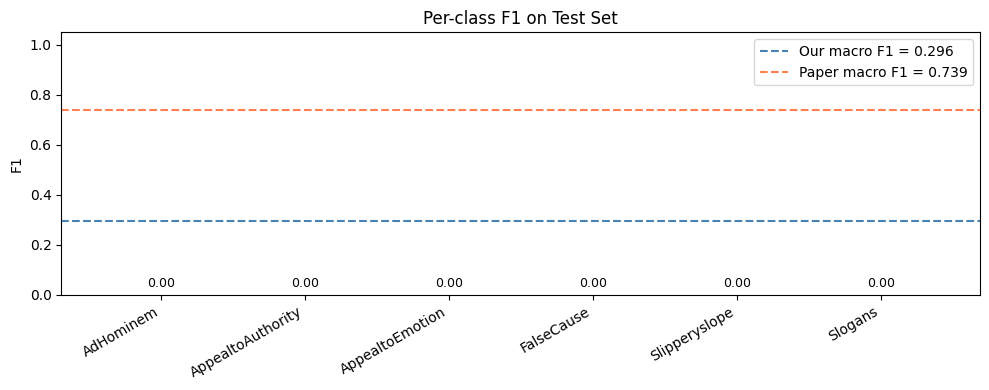

In [ ]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────
b_labels    = [l for l in LABELS if l.startswith('B-')]
clean_names = [l.replace('B-','') for l in b_labels]
class_f1s   = [cr_dict.get(l, {}).get('f1-score', 0.0) for l in b_labels]
paper_f1    = 0.7394

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(clean_names, class_f1s, color='steelblue', alpha=0.85)
ax.axhline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Our macro F1 = {macro_f1:.3f}')
ax.axhline(paper_f1, color='coral',     linestyle='--', linewidth=1.5,
           label=f'Paper macro F1 = {paper_f1:.3f}')
ax.set_ylim(0, 1.05); ax.set_ylabel('F1'); ax.set_title('Per-class F1 on Test Set')
ax.legend()
for bar, f1 in zip(bars, class_f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{f1:.2f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/per_class_f1.png', dpi=150); plt.show()

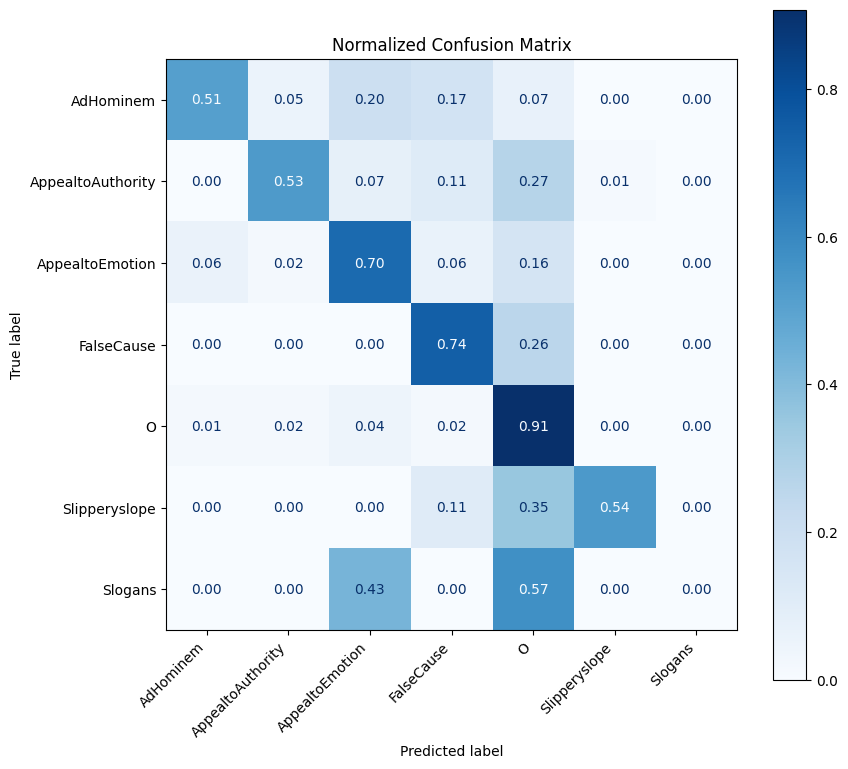

In [ ]:
# ── Normalized confusion matrix ────────────────────────────────────────────
norm_true = [t.replace('B-','').replace('I-','') for t in all_true]
norm_pred = [p.replace('B-','').replace('I-','') for p in all_pred]
classes   = sorted(set(norm_true))
cm        = confusion_matrix(norm_true, norm_pred, labels=classes, normalize='true')

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
ax.set_title('Normalized Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(f'{LOG_DIR}/confusion_matrix.png', dpi=150); plt.show()

In [ ]:
# ── Comparison vs paper baselines ─────────────────────────────────────────
comparison = pd.DataFrame([
    {'Model': 'BERT + LSTM',                 'Features': 'None',           'Macro F1': 0.4697},
    {'Model': 'BERT + LSTM',                 'Features': 'Comp + Rel',     'Macro F1': 0.5142},
    {'Model': 'BERT + BiLSTM + LSTM',        'Features': 'None',           'Macro F1': 0.5495},
    {'Model': 'BERT + BiLSTM + LSTM',        'Features': 'Comp + Rel',     'Macro F1': 0.5614},
    {'Model': 'BertFTC (bert-base-uncased)', 'Features': 'None',           'Macro F1': 0.7096},
    {'Model': 'BertFTC (bert-large-cased)',  'Features': 'None',           'Macro F1': 0.7237},
    {'Model': 'DebertaFTC',                  'Features': 'None',           'Macro F1': 0.7222},
    {'Model': 'DistilbertFTC (uncased)',     'Features': 'None',           'Macro F1': 0.7047},
    {'Model': 'MultiFusion BERT (paper)',    'Features': 'Comp+Rel+PoS',   'Macro F1': 0.7394},
    {'Model': f'Ours ({BEST_RUN_ID})',       'Features': 'Comp+Rel+PoS',   'Macro F1': round(macro_f1, 4)},
])
comparison = comparison.sort_values('Macro F1', ascending=False).reset_index(drop=True)
comparison.to_csv(f'{LOG_DIR}/results_comparison.csv', index=False)
print(comparison.to_string(index=False))

                        Model     Features  Macro F1
     MultiFusion BERT (paper) Comp+Rel+PoS    0.7394
   BertFTC (bert-large-cased)         None    0.7237
                   DebertaFTC         None    0.7222
  BertFTC (bert-base-uncased)         None    0.7096
      DistilbertFTC (uncased)         None    0.7047
         BERT + BiLSTM + LSTM   Comp + Rel    0.5614
         BERT + BiLSTM + LSTM         None    0.5495
                  BERT + LSTM   Comp + Rel    0.5142
                  BERT + LSTM         None    0.4697
Ours (exp02_multifusion_bert) Comp+Rel+PoS    0.2960


In [ ]:
# ── Save full results report ──────────────────────────────────────────────
report_path = f'{LOG_DIR}/final_report_{BEST_RUN_ID}.txt'
with open(report_path, 'w') as f:
    f.write(f'Run: {BEST_RUN_ID}\nModel: {BEST_MODEL_NAME}\n')
    f.write(f'Features: {"MultiFusion" if USE_FEATURES else "Baseline"}\n\n')
    f.write('=== Token-level Classification Report ===\n')
    f.write(classification_report(all_true, all_pred, zero_division=0))
    f.write('\n=== Span-level Report (seqeval) ===\n')
    f.write(seq_report(sent_true, sent_pred, zero_division=0))
print(f'✅ Full report saved: {report_path}')

✅ Full report saved: /content/drive/MyDrive/FallacyDetection/logs/final_report_exp02_multifusion_bert.txt


---
## ✅ All Done!

**Files saved to Drive (`FallacyDetection/logs/`):**
- `class_distribution.png` — fallacy span counts per split
- `sequence_lengths.png` — token length histogram
- `experiment_log.csv` — all training runs
- `per_class_f1.png` — per-class F1 vs paper baseline
- `confusion_matrix.png` — normalized confusion matrix
- `results_comparison.csv` — comparison table
- `final_report_{run_id}.txt` — full token + span classification reports